# 栅极电离室：实验波形、成型与物理量提取

[上一节](GIC_simulation.html)从电离径迹得到感应电流、积分电荷和前放电压。这一节从实际记录的 ADC 波形出发，依次进行基线修正、波形观察、pole-zero correction 和梯形成型，再提取幅度、时间及阴极—阳极关联。

本例使用同一 GIC 装置的实验数据。阴极为正脉冲，阳极为负脉冲；两路每条记录均为 4096 点，采样间隔 10 ns。配套文件 `gic_experiment.root` 保留原 `fall.root` 的前 1000 条事件，未更改采样值。原文件共有 5500 条记录，数据由刘杰、崔增祺提供。网页保留完整运行结果；运行代码需要将配套数据放在 notebook 同一目录。

## 1. 读取原始波形

`TTree` 中 `cathod[4096]` 与 `anode[4096]` 保存同一事件的两路波形。横轴要从 sample index 换算为时间；没有电压刻度时，纵轴保留 ADC channel，不能写成 mV。

Experimental events: 1000
******************************************************************************
*Tree    :tree      : tree                                                   *
*Entries :     1000 : Total =        32953980 bytes  File  Size =   15834568 *
*        :          : Tree compression factor =   2.08                       *
******************************************************************************
*Br    0 :cathod    : cathod[4096]/F                                         *
*Entries :     1000 : Total  Size=   16477321 bytes  File Size  =    7888608 *
*Baskets :     1000 : Basket Size=      32000 bytes  Compression=   2.09     *
*............................................................................*
*Br    1 :anode     : anode[4096]/F                                          *
*Entries :     1000 : Total  Size=   16476317 bytes  File Size  =    7930225 *
*Baskets :     1000 : Basket Size=      32000 bytes  Compression=   2.08     *
*.........................

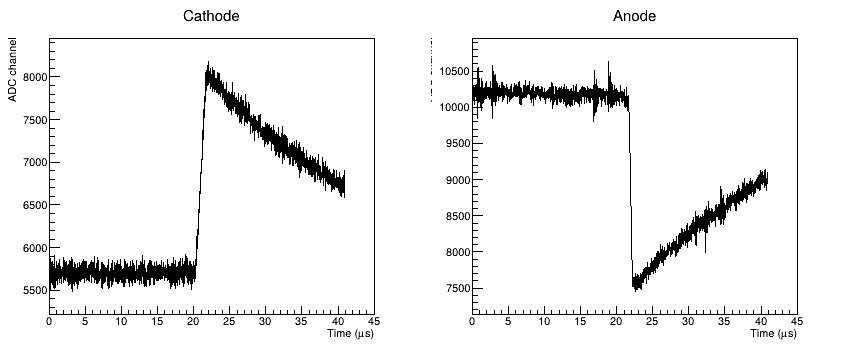

In [1]:
import ROOT
import numpy as np
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPalette(ROOT.kViridis)
f = ROOT.TFile.Open("gic_experiment.root")
tree = f.Get("tree")
tree.Print()
print(f"Experimental events: {tree.GetEntries()}")
tree.GetEntry(0)
rawc = np.array(tree.cathod, dtype=float)
rawa = np.array(tree.anode, dtype=float)
n, dt = 4096, 0.01                  # μs
t = np.arange(n, dtype=float)*dt
grc = ROOT.TGraph(n,t,rawc)
gra = ROOT.TGraph(n,t,rawa)
c = ROOT.TCanvas("exp_c","Experimental waveforms",850,380)
c.Divide(2,1)
c.cd(1)
grc.SetTitle("Cathode;Time (#mus);ADC channel")
grc.Draw("AL")
c.cd(2)
gra.SetTitle("Anode;Time (#mus);ADC channel")
gra.Draw("AL")
c.Draw()

## 2. 基线修正与波形观察

脉冲前的稳定部分给出基线 $b$，修正后 $y_k=x_k-b$。先看原始图，确认所选区间中没有信号；本例取前 1500 点。阳极再反号，后面两路都按正脉冲处理。基线的逐事件变化会直接影响幅度和长时间积分。

Baseline: cathode = 5702.13, anode = 10192.31 ADC
Baseline RMS: cathode = 68.48, anode = 74.91 ADC


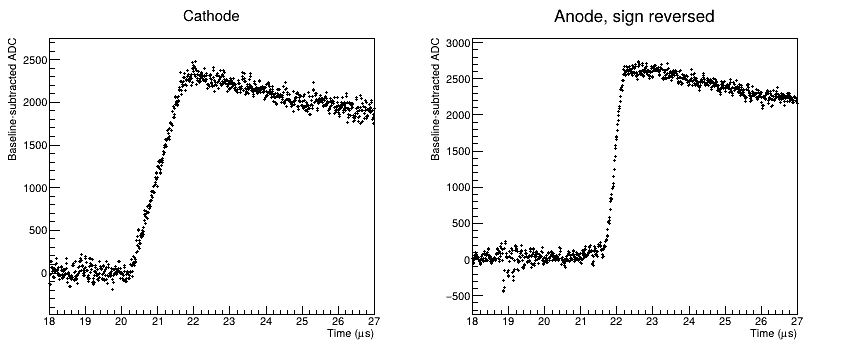

In [2]:
bc, ba = rawc[:1500].mean(), rawa[:1500].mean()
yc, ya = rawc-bc, ba-rawa
print(f"Baseline: cathode = {bc:.2f}, anode = {ba:.2f} ADC")
print(f"Baseline RMS: cathode = {yc[:1500].std():.2f}, anode = {ya[:1500].std():.2f} ADC")
gc = ROOT.TGraph(n,t,yc)
ga = ROOT.TGraph(n,t,ya)
c.Clear()
c.Divide(2,1)
for panel, graph, name in [(1,gc,"Cathode"),(2,ga,"Anode, sign reversed")]:
    c.cd(panel)
    graph.SetTitle(name+";Time (#mus);Baseline-subtracted ADC")
    graph.SetMarkerStyle(6)
    graph.Draw("AP")             # 点不连线，保留采样点与噪声的观感
    graph.GetXaxis().SetRangeUser(18,27)
c.Draw()

### median filter 与 moving average

原实例用 median filter 抑制孤立尖峰，再用 moving average 平滑波形。下面保留这个例子：101 点 median 对应 1.01 μs，随后 21 点平均对应 0.21 μs。窗口已经接近脉冲的上升时间，因此除了降噪，也会改变波形细节。median filter 是非线性处理，不能据此认为电荷仍然严格守恒。

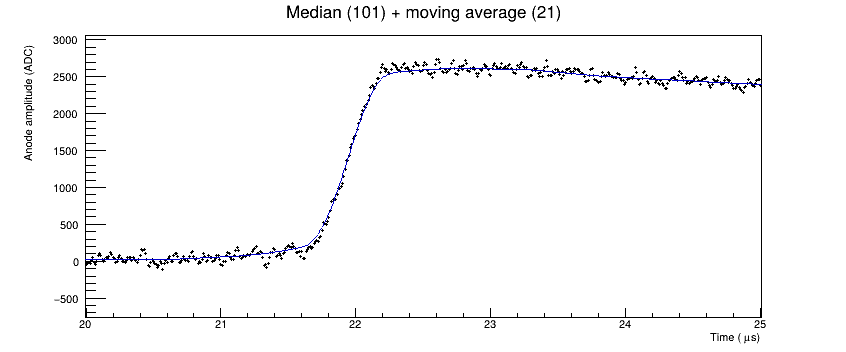

In [3]:
median = ya.copy()
for k in range(50,n-50):
    median[k] = np.median(ya[k-50:k+51])
smooth = median.copy()
for k in range(10,n-10):
    smooth[k] = median[k-10:k+11].mean()
gs = ROOT.TGraph(n,t,smooth)
c.Clear()
ga.SetTitle("Median (101) + moving average (21);Time (#mus);Anode amplitude (ADC)")
ga.Draw("AP")
ga.GetXaxis().SetRangeUser(20,25)
gs.SetLineColor(ROOT.kBlue+1)
gs.Draw("L SAME")
c.Draw()

## 3. 从前放电压到电荷估计

由前放响应可得 $\mathrm du/\mathrm dt+u/\tau=i$，因此

$$Q(t)=u(t)+\frac1\tau\int_0^t u(t')\,\mathrm dt'.$$

对基线修正后的电压做同样处理，得到与电荷成正比的量。下面直接用原始的 `ya`，不经过上面的 median filter。取 $\tau=27$ μs；在实际测量中，可用无 pile-up 脉冲的衰减尾部检查这个时间常数。修正后若有系统性的上斜或下斜，应先检查基线和 $\tau$。

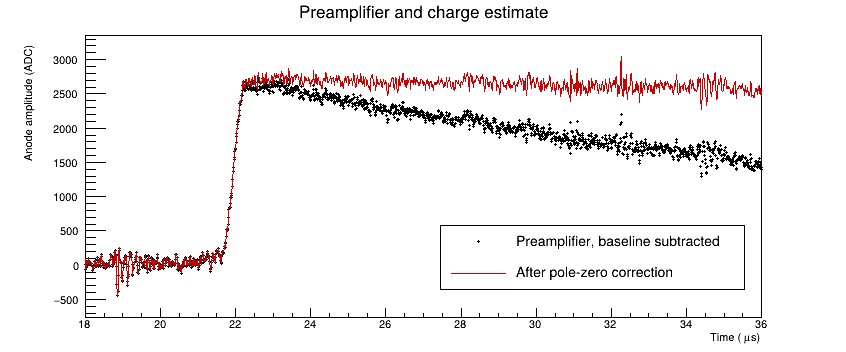

In [4]:
tau = 27.0
q = ya + dt/tau*np.cumsum(ya)         # pole-zero correction，矩形积分近似
gq = ROOT.TGraph(n,t,q)
c.Clear()
ga.SetTitle("Preamplifier and charge estimate;Time (#mus);Anode amplitude (ADC)")
ga.Draw("AP")
ga.GetXaxis().SetRangeUser(18,36)
ga.SetMaximum(1.1*max(q))
gq.SetLineColor(ROOT.kRed+1)
gq.Draw("L SAME")
leg = ROOT.TLegend(.52,.18,.88,.36)
leg.AddEntry(ga,"Preamplifier, baseline subtracted","p")
leg.AddEntry(gq,"After pole-zero correction","l")
leg.Draw()
c.Draw()

这一步去除了理想前放的指数衰减，没有把噪声消除；长时间累积还会放大基线偏差。测量电荷时，通常再用有限时间长度的成型滤波器。

## 4. 梯形成型与幅度提取

对电荷阶跃 $q_k$ 分别取两段等长的滑动平均，再作差：

$$m_k=\frac1L\sum_{j=0}^{L-1}q_{k-j},\qquad
h_k=m_k-m_{k-L-G}.$$

瞬时电荷输入会得到梯形：上升段和下降段各长 $L\Delta t$，中间 flat top 长 $G\Delta t$。有限电荷收集时间会缩短可用的平台，所以本例取 $L\Delta t=1$ μs、$G\Delta t=3$ μs，给 GIC 的电荷收集留出时间。平台幅度对应收集电荷，而不再直接依赖前放峰顶。

Shaped anode amplitude = 2705.2 ADC


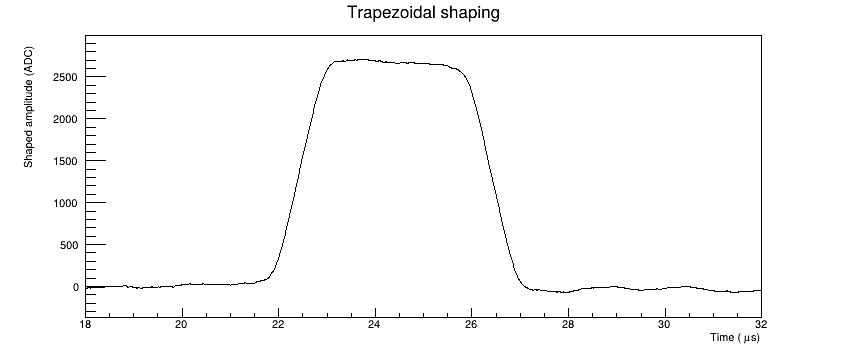

In [5]:
L, G = 100, 300                     # samples；1 μs 与 3 μs
m = np.convolve(q,np.ones(L)/L,mode="full")[:n]
shaped = m.copy()
shaped[L+G:] -= m[:n-L-G]
gh = ROOT.TGraph(n,t,shaped)
c.Clear()
gh.SetTitle("Trapezoidal shaping;Time (#mus);Shaped amplitude (ADC)")
gh.Draw("AL")
gh.GetXaxis().SetRangeUser(18,32)
c.Draw()
peak_index = 2200 + np.argmax(shaped[2200:3000])
amplitude = shaped[peak_index-10:peak_index+11].mean()
print(f"Shaped anode amplitude = {amplitude:.1f} ADC")

先看平台是否覆盖完整收集过程，再在平台上取平均。本例在搜索到的平台高点附近取 21 点平均；用于精密测量时，可用触发位置定义固定的读出区间，减少从噪声中选最大值造成的偏差。改变 $L$ 可比较噪声与成型时间的取舍；$G$ 太短时，长上升时间脉冲仍会出现 ballistic deficit。

## 5. 时间信息：上升时间与 CFD

幅度测量与时间测量使用同一条波形，但可以采用不同滤波。下面只用 21 点 moving average 稳定前沿。定义 $t_{10}$、$t_{90}$ 为前沿达到峰值 10%、90% 的时刻，上升时间为 $t_{90}-t_{10}$。

CFD 将一个延迟信号与一个衰减信号相减：

$$c_k=f y_k-y_{k-d_t}.$$

在正确的前沿上取零交叉作为时间标记。对于形状相同、幅度不同的脉冲，整体幅度因子不会改变零交叉；但 GIC 的形状随径迹方向变化，因此 CFD 时间也不能直接当成粒子的产生时刻。

t10 = 21.690; t90 = 22.139; rise time = 0.449 μs
CFD crossing = 21.934 μs, relative to record start


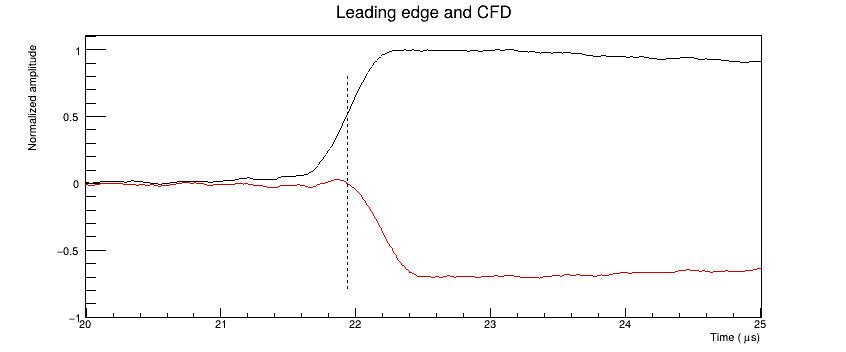

In [6]:
timing = np.convolve(ya,np.ones(21)/21,mode="same")
imax = 1900+np.argmax(timing[1900:2600])
height = timing[imax]
crossings = []
for fraction in [0.1,0.9]:
    k = 1900+np.where(timing[1900:imax+1] >= fraction*height)[0][0]
    crossing = t[k-1]+dt*(fraction*height-timing[k-1])/(timing[k]-timing[k-1])
    crossings.append(crossing)
t10,t90 = crossings
delay,fraction = 20,0.3             # 0.2 μs 延迟，衰减系数 0.3
cfd = fraction*timing.copy()
cfd[delay:] -= timing[:-delay]
start = max(1900,int(t10/dt))
stop = imax+delay
k = next(k for k in range(start,stop) if cfd[k]>0 and cfd[k+1]<=0)
tcfd = t[k]+dt*cfd[k]/(cfd[k]-cfd[k+1])
print(f"t10 = {t10:.3f}; t90 = {t90:.3f}; rise time = {t90-t10:.3f} μs")
print(f"CFD crossing = {tcfd:.3f} μs, relative to record start")
gt = ROOT.TGraph(n,t,timing/height)
gf = ROOT.TGraph(n,t,cfd/height)
c.Clear()
gt.SetTitle("Leading edge and CFD;Time (#mus);Normalized amplitude")
gt.Draw("AL")
gt.GetXaxis().SetRangeUser(20,25)
gt.SetMinimum(-1)
gf.SetLineColor(ROOT.kRed+1)
gf.Draw("L SAME")
mark = ROOT.TLine(tcfd,-.8,tcfd,.8)
mark.SetLineStyle(2)
mark.Draw()
c.Draw()

黑线是归一化的前沿，红线是 CFD 输出，虚线标出所选零交叉。

记录起点是采集系统给出的，不是电离发生时刻；上升时间也不是电子的全部漂移时间。若要由 $v_{\rm cg}=D/T_d$ 测漂移速度，应识别从电离开始到最晚电子到栅的时间 $T_d$。阴极波形及其差分可共同帮助确定这些特征，具体方法参见文献 [2]。不能直接把上面的 $t_{90}-t_{10}$ 代入。

Scope8 分别处理探测器电流、前放、采样、能量成型和定时；GIC 的两路定时还可利用阴极二次差分与阳极一次差分的边缘特征。不同定时算法的时间基准要单独确认，能量谱不应默认只保留定时成功的事件。

## 6. 逐事件提取与二维关联

把上面的基线修正、pole-zero correction 和梯形成型用于每个事件，保存阴极、阳极的成型幅度。这里不加能量或时间 cut，先看全部事件的关联。

Processed 1000 events; saved gic_amplitudes.txt


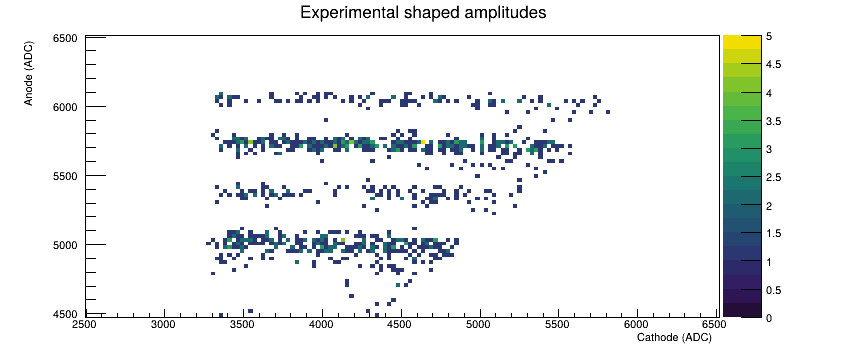

In [7]:
observables = []
for event in tree:
    amplitudes = []
    for branch,sign in [(event.cathod,1),(event.anode,-1)]:
        y = np.array(branch,dtype=float)
        y = sign*(y-y[:1500].mean())
        charge = y+dt/tau*np.cumsum(y)
        mean = np.convolve(charge,np.ones(L)/L,mode="full")[:n]
        h = mean.copy()
        h[L+G:] -= mean[:n-L-G]
        peak = 2200+np.argmax(h[2200:3000])
        amplitudes.append(h[peak-10:peak+11].mean())
    observables.append(amplitudes)
observables = np.array(observables)
c.Clear()
c.SetRightMargin(.15)
hca = ROOT.TH2D("hca","Experimental shaped amplitudes;Cathode (ADC);Anode (ADC)",300,1000,9000,350,1000,10500)
for ac,aa in observables:
    hca.Fill(ac,aa)
hca.Draw("COLZ")
hca.GetXaxis().SetRangeUser(2500,6500)
hca.GetYaxis().SetRangeUser(4500,6500)
c.Draw()
np.savetxt("gic_amplitudes.txt",observables,header="cathode_ADC anode_ADC")
print(f"Processed {len(observables)} events; saved gic_amplitudes.txt")

图中放大了四组 α 带所在区域，直方图仍填入全部 1000 个事件。阳极幅度大致分为几组，阴极幅度在每组内变化，正是上一节所解释的能量—角度信息分离。实验条带有宽度、斜率和少量离群点；对比理想图时，应区分电荷输运、电子学响应与事件选择的影响。

### 从成型幅度到物理量

用标准 α 能量确定阳极的能量刻度，例如 $E=a_a+b_a A_a$。刻度的是经过同一套处理得到的成型幅度，不能直接沿用前放峰高的系数；拟合方法可参考[标准源刻度实例](../../chapt3/coursework3.1/3.1_HpGe_gamma_calibration.html)。

阴极与阳极的增益分别刻度后，可将幅度换成上一节的 $Q_c$、$Q_a$。理想关系给出

$$\cos\theta=\frac{D}{\bar s(E)}\left(1-\frac{Q_c}{Q_a}\right),\qquad E=Q_a.$$

这里 $\bar s(E)$ 来自对应能量的电离分布。没有两路刻度或附着、栅极效率的修正时，原始幅度比只能作为角度代理，不能直接报告精确角度。

<a id="comparison"></a>

## 7. 实验与模拟波形比较

在最高能量 α 带附近取相近阳极幅度，再选择阴极幅度较低和较高的两组事件。它们分别偏向沿漂移方向和近似平行阴极的径迹，但都有有限的角度展宽。窗口从上面的实验图中选择，不是逐事件角度真值。

In [8]:
ac,aa = observables[:,0],observables[:,1]
low = (aa>5900)&(aa<6200)&(ac>3000)&(ac<3700)
high = (aa>5900)&(aa<6200)&(ac>5500)&(ac<6200)
groups = [np.where(low)[0],np.where(high)[0]]
print(f"Low cathode group: {len(groups[0])}; high cathode group: {len(groups[1])}")
averages = []
for indices in groups:
    if len(indices)==0:
        raise ValueError("Empty selection: inspect the amplitude plot")
    total_c,total_a = np.zeros(n),np.zeros(n)
    for index in indices:
        tree.GetEntry(int(index))
        xc,xa = np.array(tree.cathod,dtype=float),np.array(tree.anode,dtype=float)
        total_c += xc-xc[:1500].mean()
        total_a += xa[:1500].mean()-xa
    averages.extend([total_c/len(indices),total_a/len(indices)])

Low cathode group: 17; high cathode group: 10


比较前统一极性，再用各自前沿的 10% 位置对齐、峰值归一化。这样看的是波形形状，不是绝对增益。这里直接平均原始波形，再找对齐点，不使用强平滑；采集触发的抖动仍可能使平均前沿展宽。

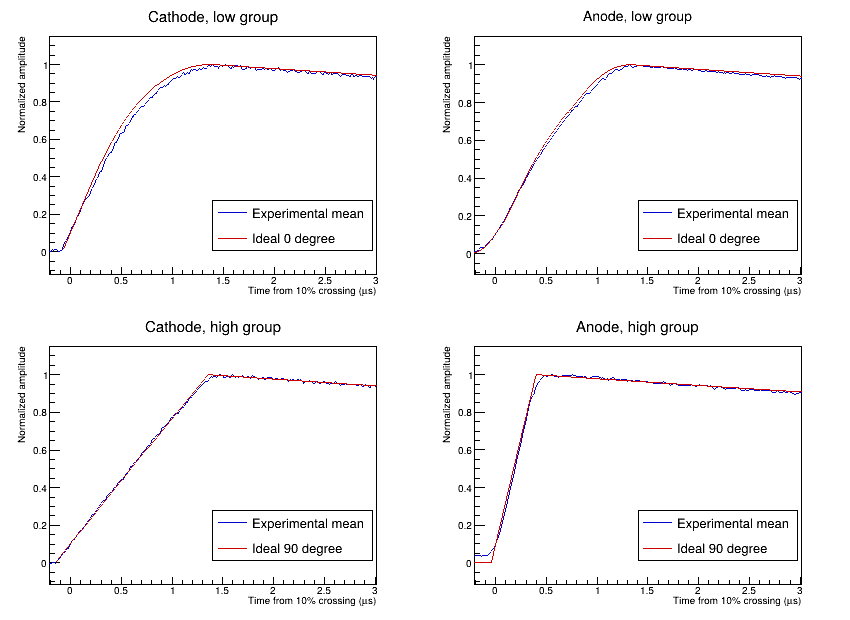

In [9]:
templates = np.loadtxt("gic_templates.txt")  # 上一节生成：t, uc0, ua0, uc90, ua90
c.Clear()
c.SetCanvasSize(850,620)
c.Divide(2,2)
compare_graphs,compare_legends = [],[]
titles=["Cathode, low group","Anode, low group","Cathode, high group","Anode, high group"]
for panel in range(4):
    c.cd(panel+1)
    exp = averages[panel]
    peak = 1900+np.argmax(exp[1900:2600])
    k = 1900+np.where(exp[1900:peak+1]>.1*exp[peak])[0][0]
    t0 = t[k-1]+dt*(.1*exp[peak]-exp[k-1])/(exp[k]-exp[k-1])
    sim = templates[:,panel+1].copy()
    ts = templates[:,0].copy()
    ks = np.where(sim>.1*max(sim))[0][0]
    ts0 = ts[ks-1]+dt*(.1*max(sim)-sim[ks-1])/(sim[ks]-sim[ks-1])
    ge = ROOT.TGraph(n,t-t0,exp/exp[peak])
    gm = ROOT.TGraph(len(ts),ts-ts0,sim/max(sim))
    ge.SetTitle(titles[panel]+";Time from 10% crossing (#mus);Normalized amplitude")
    ge.SetLineColor(ROOT.kBlue+1)
    gm.SetLineColor(ROOT.kRed+1)
    ge.Draw("AL")
    ge.GetXaxis().SetRangeUser(-.2,3)
    ge.SetMaximum(1.15)
    gm.Draw("L SAME")
    lg=ROOT.TLegend(.5,.18,.89,.35)
    lg.AddEntry(ge,"Experimental mean","l")
    lg.AddEntry(gm,"Ideal 0 degree" if panel<2 else "Ideal 90 degree","l")
    lg.Draw()
    compare_graphs.extend([ge,gm])
    compare_legends.append(lg)
c.Draw()

阳极在低阴极幅度组中的上升沿更缓，高幅度组则对应更集中的电子到达时刻；阴极本身在低幅度组中呈弯曲的上升沿，高幅度组更接近线性上升，与模型的方向依赖对应。理想曲线不含前放有限带宽、扩散、附着和栅极非屏蔽；有限选择窗中还混有不同角度，不能期待平均实验波形与单角度模板完全重合。

若形状不同，先核对气体与漂移速度、两路带宽和前放 $\tau$，再讨论输运模型；不通过任意平移、展宽或额外噪声把曲线调到重合。对齐消除了绝对时间差，归一化消除了幅度差，能量与时间的检验仍需保留未归一化的数据。

## 8. 完整信号链中的对应关系

| 阶段 | 量 | 从中提取或检查什么 |
| --- | --- | --- |
| α 在气体中电离 | $\Delta E_j$、$N_{e,j}$、位置 $s_j$ | 能量沉积与径迹 |
| 电荷漂移与电极感应 | $i_c(t)$、$i_a(t)$，积分为 $Q_c$、$Q_a$ | 能量与角度依赖 |
| 前放与数字化 | $V(t)$、ADC 波形 | 极性、时间常数、采样与噪声 |
| pole-zero correction 与梯形成型 | 电荷估计与 flat-top 幅度 | 经刻度后的能量 |
| 前沿与定时滤波 | $t_{10}$、$t_{90}$、CFD 时间 | 上升时间和相对时间标记 |
| 两路关联与校准 | $Q_c/Q_a$、能量带、波形形状 | 角度信息、输运与电子学响应 |

## 参考文献

1. J. Liu et al., “The impacts of the ballistic deficit and electron attachment on the pulse shapes of the Frisch-grid ionization chamber,” *Nucl. Instrum. Methods A* **1014**, 165751 (2021). [DOI](https://doi.org/10.1016/j.nima.2021.165751).
2. J. Liu et al., “Improved method to measure the electron drift velocity using the Frisch-grid ionization chamber,” *Nucl. Instrum. Methods A* **1004**, 165363 (2021). [DOI](https://doi.org/10.1016/j.nima.2021.165363).
3. J. Liu et al., “Research on the electron attachment of oxygen using a Frisch-grid ionization chamber,” *Nucl. Instrum. Methods A* **1013**, 165669 (2021). [DOI](https://doi.org/10.1016/j.nima.2021.165669).